# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

### PROPÓSITO DEL PROYECTO Y ACCIONES A REALIZAR

El proposito del proyecto es conocer el comportamiento de los clientes con respecto a cada plan o tarifa de prepago, compararlas y conocer si hay alguna que los clientes prefieran o si ambas tienen la misma demanda.

Acciones a realizar:

el primer paso es conocer las bases de datos de cada archivo csv, como se muestran en su almacenamiento para saber qué parametros aplicar al momento de leer cada dataframe en pandas

importaremos las librerias para leer, hacer calculos y graficos para nuestro analisis

llamaremos al metodo info para tener un panorama general de cada dataframe

-------Preprocesamiento de los datos.

--Convertir todas las columnas que sean ID a string 

detectar y en su caso eliminar los duplicados 

detectar y en su caso eliminar o reemplazar los valores ausentes


teniendo los datos depurados y unificados de todas las tablas; debemos unirlas para tener una sola base de datos con toda la informacion y conocer la media, varianza y desviacion estandar, graficar la distribucion de los datos de ambas tarifas y realizar una prueba de hipotesis para poder sacar conclusiones que lleven a una toma de decisiones

## Inicialización

In [81]:
# Cargar todas las librerías
import pandas as pd
import numpy as np
from scipy import stats as st
from matplotlib import pyplot as plt
import seaborn as sns


## Cargar datos

In [82]:
# Carga los archivos de datos en diferentes DataFrames
users_raw = pd.read_csv("/datasets/megaline_users.csv")
plans_raw = pd.read_csv("/datasets/megaline_plans.csv")
calls_raw = pd.read_csv("/datasets/megaline_calls.csv")
messages_raw = pd.read_csv("/datasets/megaline_messages.csv")
internet_raw = pd.read_csv("/datasets/megaline_internet.csv")

## Preparar los datos

##### TABLA USERS

In [83]:
users_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [84]:
users_raw.describe().round(0)

,user_id,age
count,500.0,500.0
mean,1250.0,45.0
std,144.0,17.0
min,1000.0,18.0
25%,1125.0,30.0
50%,1250.0,46.0
75%,1374.0,61.0
max,1499.0,75.0


In [85]:
users_raw.sample(8)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
20,1020,Rutha,Bell,56,"Dallas-Fort Worth-Arlington, TX MSA",2018-11-08,surf,NaN
137,1137,Allegra,Hopkins,20,"Chicago-Naperville-Elgin, IL-IN-WI MSA",2018-10-02,surf,NaN
353,1353,Emerson,Whitfield,56,"North Port-Sarasota-Bradenton, FL MSA",2018-03-27,surf,NaN
257,1257,Gabriel,O'donnell,61,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-01-29,surf,NaN
63,1063,Larhonda,Hartman,60,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-11-05,ultimate,NaN
442,1442,Terrell,Caldwell,66,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-05-25,ultimate,NaN
32,1032,Delila,Dalton,59,"Birmingham-Hoover, AL MSA",2018-06-07,ultimate,NaN
397,1397,Willow,Steele,70,"Oklahoma City, OK MSA",2018-06-01,surf,NaN


In [86]:
print(f"Hay {users_raw['user_id'].duplicated().sum()} duplicados")

Hay 0 duplicados


In [87]:
(users_raw['churn_date']<users_raw['reg_date']).sum()

0

<div class="alert alert-block alert-success">
<b>Comentario de Revisor              </b><a class="tocSkip"></a>

Muy bien, correcta esta parte de los usuarios.





</div>

##### TABLA CALLS

In [88]:
calls_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [89]:
calls_raw.describe().round(2)

,user_id,duration
count,137735.00,137735.00
mean,1247.66,6.75
std,139.42,5.84
min,1000.00,0.00
25%,1128.00,1.29
50%,1247.00,5.98
75%,1365.00,10.69
max,1499.00,37.60


In [90]:
calls_raw.sample(7)

,id,user_id,call_date,duration
24325,1091_93,1091,2018-11-06,5.51
107311,1381_48,1381,2018-09-18,0.00
14575,1059_811,1059,2018-06-30,1.47
33938,1126_853,1126,2018-08-01,19.73
94844,1336_771,1336,2018-08-23,0.00
40915,1151_93,1151,2018-10-16,0.00
122860,1434_160,1434,2018-05-09,0.00


In [91]:
print(f"Hay {calls_raw['id'].duplicated().sum()} duplicados")

Hay 0 duplicados


##### TABLA MESSAGES

In [92]:
messages_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [93]:
messages_raw.sample(7)

,id,user_id,message_date
48741,1326_278,1326,2018-09-14
5130,1046_192,1046,2018-08-15
55495,1349_54,1349,2018-12-01
1430,1014_22,1014,2018-12-14
68448,1442_20,1442,2018-12-25
65381,1419_190,1419,2018-11-24
17400,1114_294,1114,2018-12-10


In [94]:
print(f"Hay {messages_raw['id'].duplicated().sum()} duplicados")

Hay 0 duplicados


##### TABLA INTERNET

In [95]:
internet_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [96]:
internet_raw.describe().round(2)

,user_id,mb_used
count,104825.00,104825.00
mean,1242.50,366.71
std,142.05,277.17
min,1000.00,0.00
25%,1122.00,136.08
50%,1236.00,343.98
75%,1367.00,554.61
max,1499.00,1693.47


In [97]:
internet_raw.sample(7)

,id,user_id,session_date,mb_used
68396,1320_60,1320,2018-11-04,228.17
31394,1144_104,1144,2018-08-31,413.44
59170,1266_70,1266,2018-12-14,620.67
19399,1088_108,1088,2018-06-17,544.65
99530,1469_23,1469,2018-12-24,427.63
17594,1079_199,1079,2018-11-26,503.50
47761,1214_135,1214,2018-10-17,0.00


In [98]:
print(f"Hay {internet_raw['id'].duplicated().sum()} duplicados")

Hay 0 duplicados


## Tarifas

In [99]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
plans_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [100]:
# Imprime una muestra de los datos para las tarifas
plans_raw.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

La tabla de Plans contiene los dos planes y no presenta valores ausentes.
Los tipos de datos son adecuados, ya que las cantidades incluidas están en formato de numero entero y los precios unitarios tras exceder los limites del paquete estan en formato float, lo cual es apropiado porque su valor es en centavos.
No se detecto ningun problema que necesite investigacion, el unico cambio que se pudiera realizar es pasar a category la columna de plan_name. 

## Corregir datos

In [101]:
plans = plans_raw.copy()
plans['plan_name'] = plans['plan_name'].astype('category')

## Enriquecer los datos

In [102]:
plans['gb_per_month_included']=(plans['mb_per_month_included']/1024).astype(int)
plans.head(1)

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,50,15360,500,20,10,0.03,0.03,surf,15


## Usuarios/as

In [103]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
users_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [104]:
# Imprime una muestra de datos para usuarios
users_raw.sample(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
408,1408,Alaine,Robertson,40,"Baltimore-Columbia-Towson, MD MSA",2018-01-11,surf,NaN
89,1089,Malena,Kelley,70,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA",2018-09-03,surf,NaN
143,1143,Lorina,Stevens,69,"Cincinnati, OH-KY-IN MSA",2018-10-26,surf,NaN
469,1469,Rory,Nixon,75,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-06-04,surf,NaN
94,1094,Walter,Petersen,54,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-10-30,surf,2018-12-12


Esta tabla presenta tipos de datos que no son adecuados para lo que representa la variable en cuestion, empezando por el user_id que lo marca como interger y al ser un identificador tendría que ser string

las variables de nombre y apellido podrian quedarse como object o string, no existe problema alguno 

la variable age esta como interger lo cual es correcto al tratarse de una variable numerica discreta

las variables reg_date y churn date estan como objeto, al tratarse de fechas tienen que cambiarse a ese formato (datetime)

por ultimo las varibles de ciudad y el plan estan como object pero para poderlas manejar de forma eficaz al realizar un analisis se deben pasar a category

Solo presenta valores ausentes la variable de churn_date, sin embargo es normal por la naturalidad de la variable, pues se trata de la fecha de baja o que el usuario dejo de usar el servicio, seria preocupante si todos los usuarios presentasen una fecha de partida/baja 

### Corregir los datos

In [105]:
users = users_raw.copy()
users['user_id'] = users['user_id'].astype('string')
users['churn_date'] = pd.to_datetime(users['churn_date'])
users['reg_date'] = pd.to_datetime(users['reg_date'])
users[['city','plan']] = users[['city','plan']].astype('category')

### Enriquecer los datos

In [106]:
users['is_churned'] = users['churn_date'].notna().astype(int)

## Llamadas

In [107]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
calls_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [108]:
# Imprime una muestra de datos para las llamadas
calls_raw.sample(10)

,id,user_id,call_date,duration
79120,1283_76,1283,2018-12-18,4.76
5003,1022_269,1022,2018-07-05,0.13
47541,1172_132,1172,2018-10-14,1.08
23197,1084_244,1084,2018-11-29,1.01
40856,1151_34,1151,2018-09-05,16.86
66969,1240_827,1240,2018-11-16,2.37
92869,1334_237,1334,2018-09-23,0.00
45217,1163_276,1163,2018-11-05,17.93
114271,1400_621,1400,2018-04-22,15.01
72533,1257_273,1257,2018-09-27,9.13


no cuenta con valores nulos, los tipos de datos en la mayoria de sus variables se tienen que cambiar 
en las dos variaables de ID deben pasarse a tipo string 
la fecha de llamada debe pasarse a datetime
la duracion esta en float lo cual es correcto al encontrarse en minutos, con lo cual podrian medirse las estadisticas descriptivas las llamadas

### Corregir los datos

In [109]:
calls = calls_raw.copy()
calls[['id','user_id']] = calls[['id','user_id']].astype('string')
calls['call_date'] = pd.to_datetime(calls['call_date'])

### Enriquecer los datos

In [110]:
calls['year'] = calls['call_date'].dt.year
calls['month'] = calls['call_date'].dt.month

In [111]:
calls['duration_rounded'] = np.ceil(calls['duration'])
# menciona que rendondea hacia arriba aunque pase por un 1 segundo del minuto

## Mensajes

In [112]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
messages_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [113]:
# Imprime una muestra de datos para los mensajes
messages_raw.sample(5)

,id,user_id,message_date
49570,1328_528,1328,2018-06-13
9104,1066_278,1066,2018-05-04
62965,1399_30,1399,2018-09-24
24515,1145_370,1145,2018-09-05
26528,1160_41,1160,2018-04-29


no cuenta con valores nulos, los tipos de datos se deben cambiar en las dos variables de ID deberan pasarse a tipo string 

y la fecha de mensaje debe pasarse a datetime 

### Corregir los datos

In [114]:
messages = messages_raw.copy()
messages[['id','user_id']] = messages[['id','user_id']].astype('string')
messages['message_date'] = pd.to_datetime(messages['message_date'])

### Enriquecer los datos

In [115]:
messages['year'] = messages['message_date'].dt.year
messages['month'] = messages['message_date'].dt.month

## Internet

In [116]:
# Imprime la información general/resumida sobre el DataFrame de internet
internet_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [117]:
# Imprime una muestra de datos para el tráfico de internet
internet_raw.sample(5)

,id,user_id,session_date,mb_used
78328,1366_17,1366,2018-10-17,965.87
59053,1264_549,1264,2018-12-28,401.99
91293,1420_186,1420,2018-09-10,627.31
9100,1046_385,1046,2018-11-29,443.64
57957,1261_428,1261,2018-04-26,0.00


no cuenta con valores nulos, los tipos de datos se deben cambiar en las dos variables de ID deberan pasarse a tipo string

y la fecha de sesion debe pasarse a datetime

### Corregir los datos

In [118]:
internet = internet_raw.copy()
internet[['id','user_id']] = internet[['id','user_id']].astype('string')
internet['session_date'] = pd.to_datetime(internet['session_date'])

### Enriquecer los datos

In [119]:
internet['year'] = internet['session_date'].dt.year
internet['month'] = internet['session_date'].dt.month
internet.head(5)

,id,user_id,session_date,mb_used,year,month
0,1000_13,1000,2018-12-29,89.86,2018,12
1,1000_204,1000,2018-12-31,0.00,2018,12
2,1000_379,1000,2018-12-28,660.40,2018,12
3,1000_413,1000,2018-12-26,270.99,2018,12
4,1000_442,1000,2018-12-27,880.22,2018,12


## Estudiar las condiciones de las tarifas

In [120]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
plans=plans_raw.copy()
plans.head(2)

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Agregar datos por usuario

In [160]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
calls_per_month = calls.groupby(['user_id','year','month'])['id'].count().reset_index(name='calls_per_month')

In [122]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
minutes_per_month = calls.groupby(['user_id','year','month'])['duration_rounded'].sum().reset_index(name='minutes_per_month')


In [123]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
messages_per_month = messages.groupby(['user_id','year','month'])['id'].count().reset_index(name='messages_per_month')



In [124]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
internet_per_month = internet.groupby(['user_id','year','month'])['mb_used'].sum().reset_index(name='mg_total')

internet_per_month['gb_used'] = np.ceil(internet_per_month['mg_total'] / 1024)




In [125]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
usage_per_month = calls_per_month.merge(minutes_per_month,on=['user_id','year','month'],how='outer')
usage_per_month = usage_per_month.merge(messages_per_month,on=['user_id','year','month'],how='outer')
usage_per_month = usage_per_month.merge(internet_per_month,on=['user_id','year','month'],how='outer')


In [126]:
# Añade la información de la tarifa
usage_per_month = usage_per_month.merge(users[['user_id','plan']],on=['user_id'],how='left')


In [127]:
usage_per_month = usage_per_month.merge(plans,left_on='plan',right_on='plan_name',how='left')


In [128]:
usage_per_month['gb_included'] = usage_per_month['mb_per_month_included'] / 1024

In [129]:
usage_per_month = usage_per_month.fillna(0)
usage_per_month.sample(5)

,user_id,year,month,calls_per_month,minutes_per_month,messages_per_month,mg_total,gb_used,plan,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_included
756,1162,2018,10,43.0,313.0,23.0,10939.10,11.0,ultimate,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0
307,1066,2018,12,70.0,510.0,29.0,17529.09,18.0,surf,50,15360,500,20,10,0.03,0.03,surf,15.0
320,1069,2018,9,26.0,218.0,51.0,8293.23,9.0,ultimate,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0
492,1106,2018,7,84.0,603.0,0.0,18682.76,19.0,surf,50,15360,500,20,10,0.03,0.03,surf,15.0
867,1185,2018,7,77.0,578.0,0.0,29354.86,29.0,ultimate,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0


In [130]:
# Calcula el ingreso mensual para cada usuario
usage_per_month['ext_minutes'] = (usage_per_month['minutes_per_month']-usage_per_month['minutes_included']).clip(lower=0)
usage_per_month['ext_messages'] = (usage_per_month['messages_per_month']-usage_per_month['messages_included']).clip(lower=0)
usage_per_month['ext_gb'] = (usage_per_month['gb_used']-usage_per_month['gb_included']).clip(lower=0)

In [131]:
usage_per_month['ext_cost_min'] = usage_per_month['ext_minutes'] * usage_per_month['usd_per_minute']
usage_per_month['ext_cost_messages'] = usage_per_month['ext_messages'] * usage_per_month['usd_per_message']
usage_per_month['ext_cost_gb'] = usage_per_month['ext_gb'] * usage_per_month['usd_per_gb']

In [132]:
usage_per_month['monthly_total_cost'] = usage_per_month['ext_cost_min'] + usage_per_month['ext_cost_messages'] + usage_per_month['ext_cost_gb'] + usage_per_month['usd_monthly_pay']

In [133]:
usage_per_month.sample(5)

,user_id,year,month,calls_per_month,minutes_per_month,messages_per_month,mg_total,gb_used,plan,messages_included,...,usd_per_minute,plan_name,gb_included,ext_minutes,ext_messages,ext_gb,ext_cost_min,ext_cost_messages,ext_cost_gb,monthly_total_cost
1193,1258,2018,9,7.0,42.0,49.0,19041.96,19.0,surf,50,...,0.03,surf,15.0,0.0,0.0,4.0,0.00,0.0,40.0,60.00
1531,1338,2018,9,95.0,599.0,0.0,17778.67,18.0,surf,50,...,0.03,surf,15.0,99.0,0.0,3.0,2.97,0.0,30.0,52.97
426,1090,2018,11,62.0,469.0,24.0,21358.72,21.0,surf,50,...,0.03,surf,15.0,0.0,0.0,6.0,0.00,0.0,60.0,80.00
790,1170,2018,9,13.0,90.0,3.0,7189.24,8.0,surf,50,...,0.03,surf,15.0,0.0,0.0,0.0,0.00,0.0,0.0,20.00
1771,1389,2018,10,69.0,511.0,0.0,20259.49,20.0,ultimate,1000,...,0.01,ultimate,30.0,0.0,0.0,0.0,0.00,0.0,0.0,70.00


## Estudia el comportamiento de usuario

### Llamadas

In [134]:

# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
avg_min = usage_per_month.groupby(['month','plan'])['minutes_per_month'].mean().round(2).reset_index(name='minutes_per_month')
avg_min.head(7)

,month,plan,minutes_per_month
0,1,surf,203.00
1,1,ultimate,193.50
2,2,surf,297.00
3,2,ultimate,403.14
4,3,surf,330.00
5,3,ultimate,304.25
6,4,surf,351.54


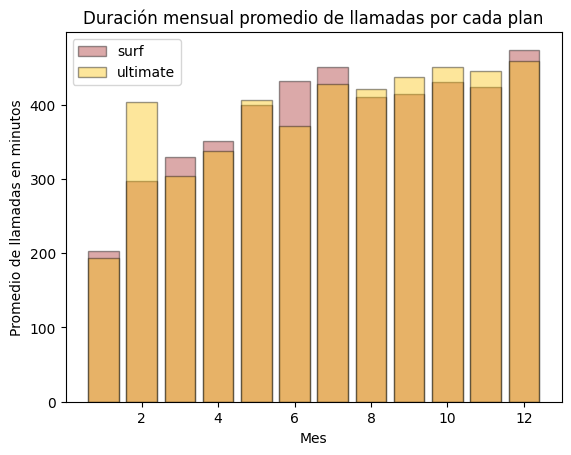

In [135]:
colors = {'surf':'brown',
         'ultimate':'#FAC205'
         }

for plan in avg_min['plan'].unique():
    subset = avg_min[avg_min['plan'] == plan]
    plt.bar(subset['month'], subset['minutes_per_month'], label=plan, alpha=.4, color=colors[plan], edgecolor='black')

plt.xlabel('Mes')
plt.ylabel('Promedio de llamadas en minutos')
plt.title('Duración mensual promedio de llamadas por cada plan')
plt.legend()
plt.show()


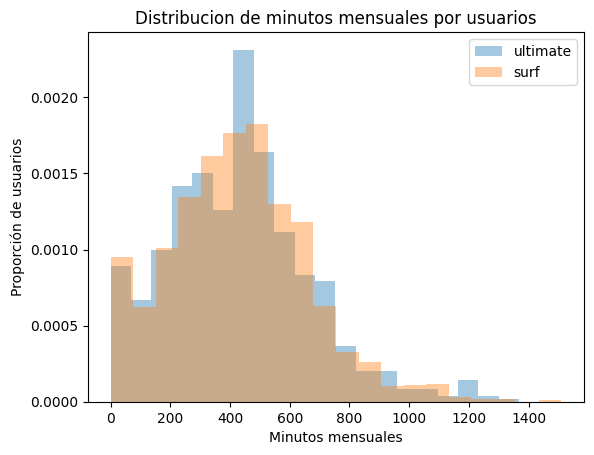

In [136]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
for plan in usage_per_month['plan'].unique():
    subdf = usage_per_month[usage_per_month['plan'] == plan]
    plt.hist(subdf['minutes_per_month'], alpha=0.4, label=plan, bins=20,density=True)

plt.xlabel('Minutos mensuales')
plt.ylabel('Proporción de usuarios')
plt.title('Distribucion de minutos mensuales por usuarios')
plt.legend()
plt.show()


In [137]:

usage_per_month.groupby('plan')['minutes_per_month'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
surf,1573.0,428.75,234.45,0.0,272.0,425.0,576.00,1510.0
ultimate,720.0,430.45,240.51,0.0,260.0,424.0,565.25,1369.0


In [138]:
# Calcula la media y la varianza de la duración mensual de llamadas.
mean = usage_per_month['minutes_per_month'].mean()
variance = np.var(usage_per_month['minutes_per_month'])
desv_est = np.std(usage_per_month['minutes_per_month'])
print(f'La media de la duracion mensual de llamadas es {mean:.2f} con una varianza de {variance:.2f} y desviación estandar de {desv_est:.2f} ')

La media de la duracion mensual de llamadas es 429.28 con una varianza de 55822.82 y desviación estandar de 236.27 


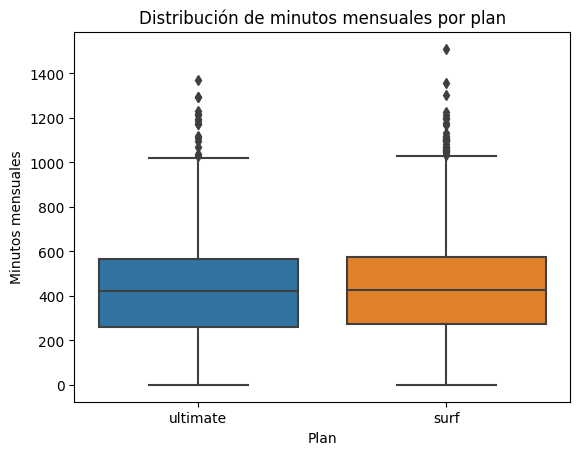

In [139]:

# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
sns.boxplot(x='plan',
            y='minutes_per_month',
            data=usage_per_month)

plt.title('Distribución de minutos mensuales por plan')
plt.xlabel('Plan')
plt.ylabel('Minutos mensuales')
plt.show()


El consumo mensual de minutos es prácticamente igual entre los planes Surf y Ultimate, tanto en términos de media como de mediana (la media es de 428 y 430 respectivamente; y la mediana es de 425 y 430 respectivamente). 

Esto indica que el tipo de plan no influye significativamente en el comportamiento de uso de llamadas. Sin embargo, en el plan Surf, el límite de minutos es de 500, y se observa que una parte considerable de usuarios lo supera (cuartil 75%), lo que puede generar ingresos adicionales por excedentes. 

En contraste, el límite del plan Ultimate (3000 minutos) está muy por encima del consumo habitual, incluso considerando los valores máximos observados, por lo que es poco probable que este plan genere ingresos adicionales por llamadas.

Por ultimo en el grafico de barras se observa que los meses donde se tiene mas uso de minutos son los meses de julio y diciembre (periodo vacacional)

### Mensajes

In [140]:
# Compara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan

usage_per_month.groupby('plan')['messages_per_month'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
surf,1573.0,31.16,33.57,0.0,3.0,24.0,47.0,266.0
ultimate,720.0,37.55,34.77,0.0,7.0,30.0,61.0,166.0


In [141]:
usage_per_month.groupby('plan')['messages_per_month'].median()


plan
surf        24.0
ultimate    30.0
Name: messages_per_month, dtype: float64

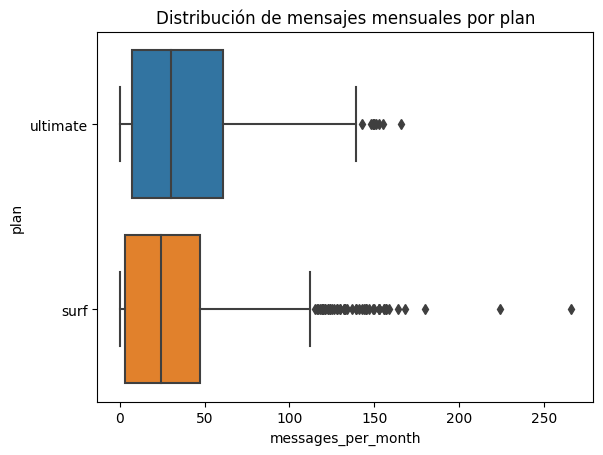

In [142]:
sns.boxplot(x='messages_per_month',
            y='plan',
            data=usage_per_month)

plt.title('Distribución de mensajes mensuales por plan')
plt.show()

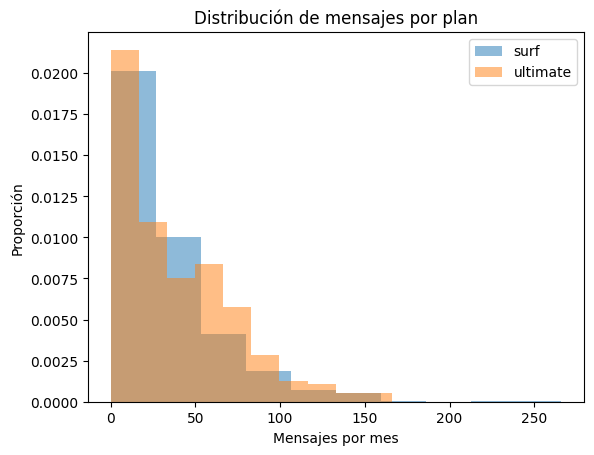

In [143]:

for plan, df_plan in usage_per_month.groupby('plan'):
    plt.hist(df_plan['messages_per_month'],
             alpha=0.5,
             label=plan,
             density=True)

plt.legend()
plt.xlabel('Mensajes por mes')
plt.ylabel('Proporción')
plt.title('Distribución de mensajes por plan')
plt.show()



Los usuarios del plan Ultimate envían en promedio más mensajes que los del plan Surf (37 vs 31). Esta diferencia también se observa en la mediana, Ultimate registra 30 mensajes mensuales mientras que surf registra 24. Sin embargo, en ambos planes el consumo típico se mantiene muy por debajo del límite incluido en cada tarifa (como se observa en el grafico de cajas y bigotes). 

En el plan Surf, aunque algunos usuarios superan el límite de 50 mensajes, la mayoría no lo hace. En el plan Ultimate, el límite es de 1000 mensajes que es mayor al consumo habitual, por lo que es poco probable que los mensajes generen ingresos adicionales significativos.

Adicionalmente, la distribución del número de mensajes enviados por mes es muy similar en ambos planes como se observa en el histograma por densidad. La mayoría de los usuarios se concentra en rangos bajos y moderados de consumo, y no se observan diferencias sustanciales en la forma de la distribución. Esto sugiere que el tipo de plan no influye en el comportamiento de envío de mensajes.


### Internet

In [144]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
usage_per_month.groupby('plan')['gb_used'].mean().round(2)


plan
surf        16.67
ultimate    17.31
Name: gb_used, dtype: float64

In [145]:

usage_per_month.groupby('plan')['gb_used'].median().round(2)



plan
surf        17.0
ultimate    17.0
Name: gb_used, dtype: float64

In [146]:
usage_per_month.groupby('plan')['gb_used'].describe().round(2)


,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
surf,1573.0,16.67,7.85,0.0,12.0,17.0,21.0,70.0
ultimate,720.0,17.31,7.67,0.0,13.0,17.0,21.0,46.0


<function matplotlib.pyplot.show(close=None, block=None)>

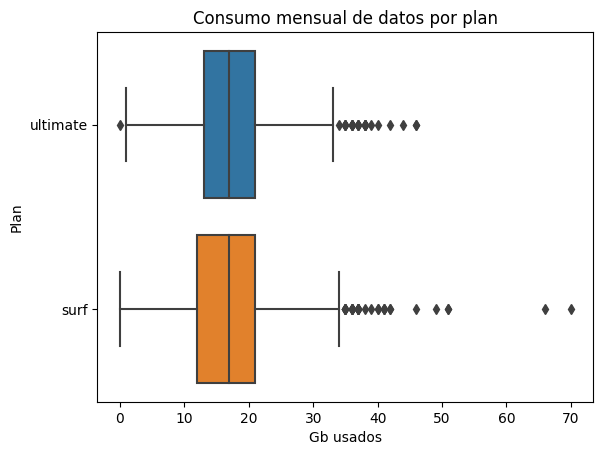

In [147]:

sns.boxplot(x='gb_used',
            y='plan',
            data=usage_per_month)

plt.title('Consumo mensual de datos por plan')
plt.xlabel('Gb usados')
plt.ylabel('Plan')
plt.show


Los usuarios de ambos planes consumen prácticamente la misma cantidad de datos móviles. El promedio mensual es de 16.67 GB en Surf y 17.31 GB en Ultimate, con una mediana idéntica de 17 GB en ambos planes.

Sin embargo, el plan Surf solo incluye 15 GB y Ultimate incluye 30 GB, por lo que una parte considerable de los usuarios de Surf excede su límite mensual y debe pagar cargos adicionales, mientras que los usuarios de Ultimate difícilmente alcanzan el límite incluido. Por lo tanto, es probable que los ingresos adicionales por datos móviles provengan principalmente del plan Surf.

## Ingreso

In [148]:
usage_per_month.groupby('plan')['monthly_total_cost'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
surf,1573.0,60.71,55.39,20.0,20.0,40.36,80.36,590.37
ultimate,720.0,72.31,11.40,70.0,70.0,70.00,70.00,182.00


In [149]:
usage_per_month.groupby('plan')['monthly_total_cost'].var()

plan
surf        3067.835152
ultimate     129.848486
Name: monthly_total_cost, dtype: float64

In [150]:
usage_per_month.groupby('plan')['ext_cost_min'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
surf,1573.0,1.84,3.77,0.0,0.0,0.0,2.28,30.3
ultimate,720.0,0.00,0.00,0.0,0.0,0.0,0.00,0.0


In [151]:
usage_per_month.groupby('plan')['ext_cost_gb'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
surf,1573.0,38.65,54.46,0.0,0.0,20.0,60.0,550.0
ultimate,720.0,2.31,11.40,0.0,0.0,0.0,0.0,112.0


In [152]:
usage_per_month.groupby('plan')['ext_cost_messages'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
surf,1573.0,0.21,0.58,0.0,0.0,0.0,0.0,6.48
ultimate,720.0,0.00,0.00,0.0,0.0,0.0,0.0,0.00


In [153]:
total_income = usage_per_month.groupby('plan')['monthly_total_cost'].sum().reset_index()
print(total_income)

       plan  monthly_total_cost
0      surf            95491.18
1  ultimate            52066.00


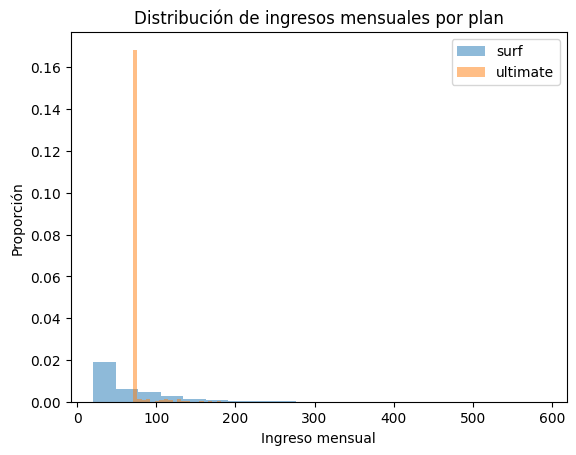

In [154]:
for plan, df_plan in usage_per_month.groupby('plan'):
    plt.hist(df_plan['monthly_total_cost'],
             alpha=0.5,
             label=plan,
             bins=20,
             density=True)

plt.legend()
plt.xlabel('Ingreso mensual')
plt.ylabel('Proporción')
plt.title('Distribución de ingresos mensuales por plan')
plt.show()

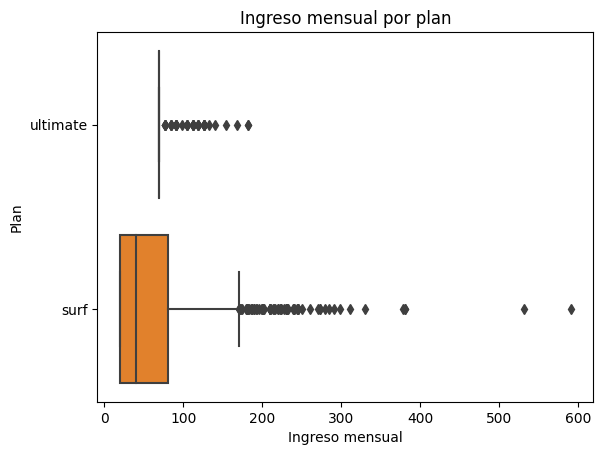

In [155]:

sns.boxplot(x='monthly_total_cost',
            y='plan',
            data=usage_per_month)

plt.title('Ingreso mensual por plan')
plt.xlabel('Ingreso mensual')
plt.ylabel('Plan')
plt.show()



El plan Surf genera mayores ingresos totales (95,491.18) en comparación con Ultimate (52,066.00). Esta diferencia se explica por los limites mas bajos del plan Surf, lo que provoca que una proporción considerable de usuarios supere los limites y tengan cargos adicionales por excedentes, sobretodo de minutos y datos móviles.

Por otro lado, el plan Ultimate presenta ingresos más estables y concentrados alrededor de la tarifa mensual fija, con poca variabilidad y escasos cargos adicionales. Esto sugiere que sus límites cubren adecuadamente el consumo habitual de sus usuarios.

Por lo que, el plan Surf resulta más beneficioso para la empresa debido a la frecuencia de ingresos adicionales generados por excedentes.

## Prueba las hipótesis estadísticas

##### H0 = El ingreso promedio mensual es igual en ambos planes

##### H1 = El ingreso promedio mensual es diferente entre los planes

In [156]:

# Prueba las hipótesis

surf = usage_per_month[usage_per_month['plan'] == 'surf']['monthly_total_cost']
ultimate = usage_per_month[usage_per_month['plan'] == 'ultimate']['monthly_total_cost']
alpha = 0.05
result = st.ttest_ind(surf, ultimate,equal_var=False)
print('valor p:',result.pvalue)

if result.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No se rechaza h0")

    

valor p: 3.1703905481135734e-15
Rechazamos la hipótesis nula


##### H0: El ingreso promedio mensual de los usuarios del área NY-NJ es igual al de los usuarios de otras regiones.
##### H1: El ingreso promedio mensual de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.

In [157]:
usage_per_month = usage_per_month.merge(users[['user_id', 'city']],on='user_id',how='left')
usage_per_month.sample()

,user_id,year,month,calls_per_month,minutes_per_month,messages_per_month,mg_total,gb_used,plan,messages_included,...,plan_name,gb_included,ext_minutes,ext_messages,ext_gb,ext_cost_min,ext_cost_messages,ext_cost_gb,monthly_total_cost,city
2072,1456,2018,12,62.0,425.0,43.0,12405.6,13.0,ultimate,1000,...,ultimate,30.0,0.0,0.0,0.0,0.0,0.0,0.0,70.0,"Minneapolis-St. Paul-Bloomington, MN-WI MSA"


In [158]:
# Prueba las hipótesis

ny_nj = usage_per_month[usage_per_month['city'] == 'New York-Newark-Jersey City, NY-NJ-PA MSA']['monthly_total_cost']
other = usage_per_month[usage_per_month['city'] != 'New York-Newark-Jersey City, NY-NJ-PA MSA']['monthly_total_cost']
alpha = 0.05
result = st.ttest_ind(ny_nj, other,equal_var=False)
print('valor p:',result.pvalue)

if result.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No se rechaza h0")



valor p: 0.0335256158853001
Rechazamos la hipótesis nula


## Conclusión general


Se analizaron los patrones de consumo de los usuarios de los planes Surf y Ultimate, así como los ingresos generados por cada uno, con el objetivo de determinar cuál plan resulta más rentable para la empresa.

Mensajes:
Ambos planes presentan comportamientos similares. Aunque los usuarios del plan Ultimate envían ligeramente más mensajes en promedio y mediana, la diferencia no es considerable. En general, el uso de mensajes no parece ser un factor determinante en la generación de ingresos adicionales.

Minutos de llamadas:
El consumo promedio mensual de minutos es muy similar entre ambos planes (aprox. 428–430 minutos). Sin embargo, el límite del plan Surf (500 minutos) es mucho menor que el del plan Ultimate (3000 minutos), lo que provoca que algunos usuarios del plan Surf superen el límite y generen ingresos adicionales. En el plan Ultimate es poco probable que los usuarios excedan el límite de minutos.

Datos móviles:
El consumo promedio de datos también es similar entre planes (alrededor de 17 GB mensuales), pero el plan Surf incluye solo 15 GB, mientras que Ultimate incluye 30 GB. por lo que muchos usuarios del plan Surf excedan el límite y generen cargos adicionales, mientras que en Ultimate esto ocurre con menor frecuencia.

Las estadísticas descriptivas de los ingresos por planes demostraron que el plan Surf tiene mayor variabilidad en ingresos mensuales y el plan Ultimate presenta ingresos mucho más estables, concentrados alrededor de la tarifa fija mensual.

La suma total de ingresos indica que Surf genera mayores ingresos totales que Ultimate, principalmente debido a los cargos por excedentes en gb.

Se realizó una prueba t para comparar los ingresos promedio entre los planes Surf y Ultimate.
El valor p fue significativamente menor que 0.05, por lo que se rechazó la hipótesis nula.
Esto indica que existe una diferencia estadísticamente significativa entre los ingresos promedio de ambos planes.

También se probó si el ingreso promedio de los usuarios del área NY-NJ difiere del resto de las regiones.
Con un valor p = 0.0335 (< 0.05), se concluye que existe una diferencia estadísticamente significativa entre regiones